In [1]:
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt

SEED = 42
rng = np.random.default_rng(SEED)

def largest_cc_size(G):
    if G.number_of_nodes() == 0:
        return 0
    return len(max(nx.connected_components(G), key=len))

def largest_cc_fraction(G):
    n = G.number_of_nodes()
    return 0.0 if n == 0 else largest_cc_size(G) / n

def er_graph_from_k(n, k, seed=None):
    p = k / (n - 1)
    return nx.erdos_renyi_graph(n=n, p=p, seed=seed), p


k=0.5  p=0.000125  LCC fraction=0.004
k=0.8  p=0.000200  LCC fraction=0.015
k=  1  p=0.000250  LCC fraction=0.047
k=1.2  p=0.000300  LCC fraction=0.153
k=1.5  p=0.000375  LCC fraction=0.546
k=  2  p=0.000500  LCC fraction=0.789
k=  3  p=0.000750  LCC fraction=0.945


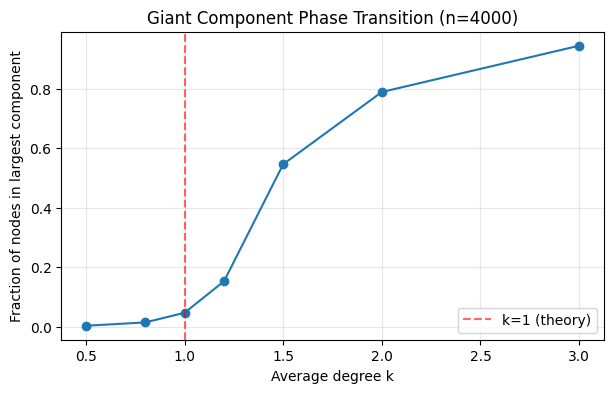


Approx threshold: around k ≈ 1 (giant component emerges near 1).


In [2]:
n = 4000
ks = [0.5, 0.8, 1, 1.2, 1.5, 2, 3]

fractions = []
ps_used = []

for k in ks:
    G, p = er_graph_from_k(n, k, seed=SEED)
    ps_used.append(p)
    fractions.append(largest_cc_fraction(G))

for k, p, f in zip(ks, ps_used, fractions):
    print(f"k={k:>3}  p={p:.6f}  LCC fraction={f:.3f}")

plt.figure(figsize=(7,4))
plt.plot(ks, fractions, marker="o")
plt.axvline(1.0, color="red", linestyle="--", alpha=0.6, label="k=1 (theory)")
plt.xlabel("Average degree k")
plt.ylabel("Fraction of nodes in largest component")
plt.title("Giant Component Phase Transition (n=4000)")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

print("\nApprox threshold: around k ≈ 1 (giant component emerges near 1).")


In [3]:
n = 5000
m = 3
G0 = nx.barabasi_albert_graph(n=n, m=m, seed=SEED)

print("BA graph")
print("  n:", G0.number_of_nodes())
print("  m:", m)
print("  edges:", G0.number_of_edges())
print("  initial LCC fraction:", largest_cc_fraction(G0))


BA graph
  n: 5000
  m: 3
  edges: 14991
  initial LCC fraction: 1.0


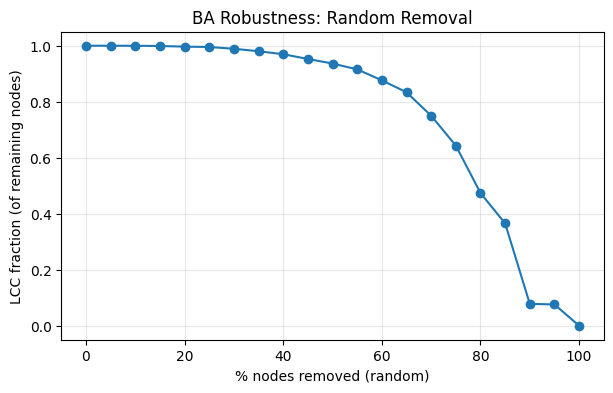

In [4]:
fractions_remove = np.arange(0, 101, 5)  # percent removed
random_curve = []

nodes = list(G0.nodes())
rng.shuffle(nodes)

for pct in fractions_remove:
    remove_count = int(round((pct / 100) * n))
    removed = set(nodes[:remove_count])

    G = G0.copy()
    G.remove_nodes_from(removed)
    random_curve.append(largest_cc_fraction(G))

plt.figure(figsize=(7,4))
plt.plot(fractions_remove, random_curve, marker="o")
plt.xlabel("% nodes removed (random)")
plt.ylabel("LCC fraction (of remaining nodes)")
plt.title("BA Robustness: Random Removal")
plt.grid(True, alpha=0.3)
plt.show()


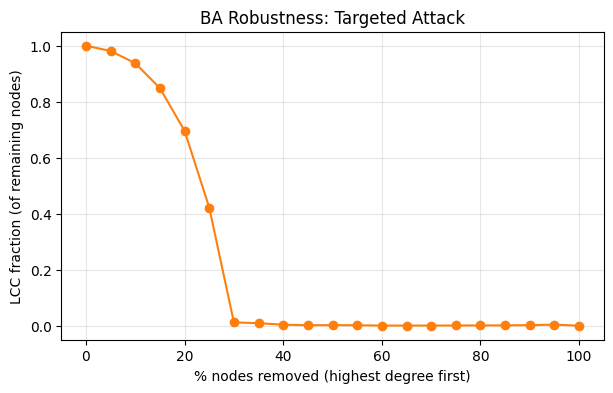

In [5]:
target_curve = []

deg_sorted = sorted(G0.degree(), key=lambda x: x[1], reverse=True)
targets = [v for v, d in deg_sorted]

for pct in fractions_remove:
    remove_count = int(round((pct / 100) * n))
    removed = set(targets[:remove_count])

    G = G0.copy()
    G.remove_nodes_from(removed)
    target_curve.append(largest_cc_fraction(G))

plt.figure(figsize=(7,4))
plt.plot(fractions_remove, target_curve, marker="o", color="tab:orange")
plt.xlabel("% nodes removed (highest degree first)")
plt.ylabel("LCC fraction (of remaining nodes)")
plt.title("BA Robustness: Targeted Attack")
plt.grid(True, alpha=0.3)
plt.show()


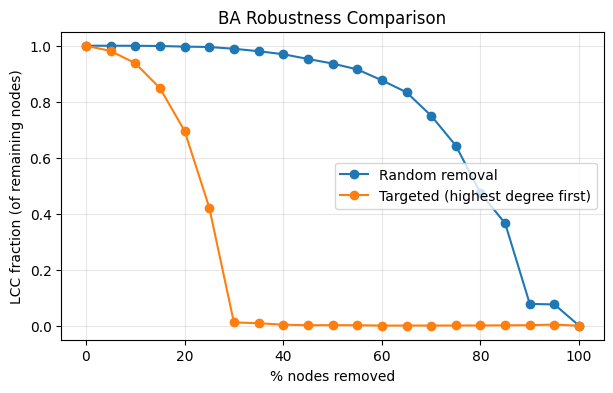

Why targeted attack is more damaging:
  BA graphs have hubs that carry many shortest paths and hold the network together.
  Random removal usually hits low-degree nodes, so the core stays connected longer.
  Targeted removal deletes hubs early, rapidly fragmenting the graph and shrinking the LCC.


In [6]:
plt.figure(figsize=(7,4))
plt.plot(fractions_remove, random_curve, marker="o", label="Random removal")
plt.plot(fractions_remove, target_curve, marker="o", label="Targeted (highest degree first)")
plt.xlabel("% nodes removed")
plt.ylabel("LCC fraction (of remaining nodes)")
plt.title("BA Robustness Comparison")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

print("Why targeted attack is more damaging:")
print("  BA graphs have hubs that carry many shortest paths and hold the network together.")
print("  Random removal usually hits low-degree nodes, so the core stays connected longer.")
print("  Targeted removal deletes hubs early, rapidly fragmenting the graph and shrinking the LCC.")
